In [1]:
import os
import re
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

file_path = next(iter(uploaded.keys()))
print(f"Uploaded file: {file_path}")

assert Path(file_path).exists(), "File not found after upload."

Saving Apache_2k.log to Apache_2k.log
Uploaded file: Apache_2k.log


In [3]:
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw_lines = f.readlines()

print("Total raw lines:", len(raw_lines))
print("\nFirst 5 raw lines:\n")

for line in raw_lines[:5]:
    print(line.rstrip())

Total raw lines: 2000

First 5 raw lines:

[Sun Dec 04 04:47:44 2005] [notice] workerEnv.init() ok /etc/httpd/conf/workers2.properties
[Sun Dec 04 04:47:44 2005] [error] mod_jk child workerEnv in error state 6
[Sun Dec 04 04:51:08 2005] [notice] jk2_init() Found child 6725 in scoreboard slot 10
[Sun Dec 04 04:51:09 2005] [notice] jk2_init() Found child 6726 in scoreboard slot 8
[Sun Dec 04 04:51:09 2005] [notice] jk2_init() Found child 6728 in scoreboard slot 6


In [4]:
PATTERNS = [
    re.compile(
        r'^\[(?P<timestamp>[^\]]+)\]\s+\[(?P<level>[^\]]+)\]\s+\[client\s+(?P<client>[^\]]+)\]\s+(?P<message>.*)$'
    ),
    re.compile(
        r'^\[(?P<timestamp>[^\]]+)\]\s+\[(?P<level>[^\]]+)\]\s+(?P<message>.*)$'
    )
]

def parse_log_line(line: str):
    line = line.strip()

    if not line:
        return {
            "timestamp_raw": None,
            "log_level": None,
            "client": None,
            "message": None,
            "parsed_status": "blank"
        }

    for pattern in PATTERNS:
        match = pattern.match(line)
        if match:
            groups = match.groupdict()
            return {
                "timestamp_raw": groups.get("timestamp"),
                "log_level": groups.get("level"),
                "client": groups.get("client"),
                "message": groups.get("message").strip() if groups.get("message") else "",
                "parsed_status": "success"
            }

    return {
        "timestamp_raw": None,
        "log_level": None,
        "client": None,
        "message": line,
        "parsed_status": "unparsed"
    }

print("Parser function created successfully.")

Parser function created successfully.


In [15]:
records = []

for i, line in enumerate(raw_lines, start=1):
    row = parse_log_line(line)
    row["line_no"] = i
    row["raw_line"] = line.rstrip("\n")
    records.append(row)

df = pd.DataFrame(records)

print("Parsed rows:", len(df))
display(df.head(10))

Parsed rows: 2000


,timestamp_raw,log_level,client,message,parsed_status,line_no,raw_line
0,Sun Dec 04 04:47:44 2005,notice,None,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,1,[Sun Dec 04 04:47:44 2005] [notice] workerEnv....
1,Sun Dec 04 04:47:44 2005,error,None,mod_jk child workerEnv in error state 6,success,2,[Sun Dec 04 04:47:44 2005] [error] mod_jk chil...
2,Sun Dec 04 04:51:08 2005,notice,None,jk2_init() Found child 6725 in scoreboard slot 10,success,3,[Sun Dec 04 04:51:08 2005] [notice] jk2_init()...
3,Sun Dec 04 04:51:09 2005,notice,None,jk2_init() Found child 6726 in scoreboard slot 8,success,4,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...
4,Sun Dec 04 04:51:09 2005,notice,None,jk2_init() Found child 6728 in scoreboard slot 6,success,5,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...
5,Sun Dec 04 04:51:14 2005,notice,None,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,6,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....
6,Sun Dec 04 04:51:14 2005,notice,None,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,7,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....
7,Sun Dec 04 04:51:14 2005,notice,None,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,8,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....
8,Sun Dec 04 04:51:18 2005,error,None,mod_jk child workerEnv in error state 6,success,9,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...
9,Sun Dec 04 04:51:18 2005,error,None,mod_jk child workerEnv in error state 6,success,10,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...


In [6]:
df["timestamp_raw"] = df["timestamp_raw"].astype("string").str.strip()

df["timestamp"] = pd.to_datetime(
    df["timestamp_raw"],
    format="%a %b %d %H:%M:%S %Y",
    errors="coerce"
)

fallback_mask = df["timestamp"].isna() & df["timestamp_raw"].notna()
df.loc[fallback_mask, "timestamp"] = pd.to_datetime(
    df.loc[fallback_mask, "timestamp_raw"],
    errors="coerce"
)

df["log_level"] = df["log_level"].fillna("unknown").astype(str).str.lower()
df["client"] = df["client"].fillna("unknown").astype(str)
df["message"] = df["message"].fillna("").astype(str).str.strip()

df["parsed_status"] = df["parsed_status"].fillna("unparsed")
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()

parsed_df = df[df["parsed_status"] == "success"].copy()
valid_df = parsed_df[parsed_df["timestamp"].notna()].copy()

print("After cleaning:")
print("Parsed rows:", len(parsed_df))
print("Valid timestamp rows:", len(valid_df))

display(df.head(10))

After cleaning:
Parsed rows: 2000
Valid timestamp rows: 2000


,timestamp_raw,log_level,client,message,parsed_status,line_no,raw_line,timestamp,date,hour,weekday
0,Sun Dec 04 04:47:44 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,1,[Sun Dec 04 04:47:44 2005] [notice] workerEnv....,2005-12-04 04:47:44,2005-12-04,4,Sunday
1,Sun Dec 04 04:47:44 2005,error,unknown,mod_jk child workerEnv in error state 6,success,2,[Sun Dec 04 04:47:44 2005] [error] mod_jk chil...,2005-12-04 04:47:44,2005-12-04,4,Sunday
2,Sun Dec 04 04:51:08 2005,notice,unknown,jk2_init() Found child 6725 in scoreboard slot 10,success,3,[Sun Dec 04 04:51:08 2005] [notice] jk2_init()...,2005-12-04 04:51:08,2005-12-04,4,Sunday
3,Sun Dec 04 04:51:09 2005,notice,unknown,jk2_init() Found child 6726 in scoreboard slot 8,success,4,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...,2005-12-04 04:51:09,2005-12-04,4,Sunday
4,Sun Dec 04 04:51:09 2005,notice,unknown,jk2_init() Found child 6728 in scoreboard slot 6,success,5,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...,2005-12-04 04:51:09,2005-12-04,4,Sunday
5,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,6,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
6,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,7,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
7,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,8,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
8,Sun Dec 04 04:51:18 2005,error,unknown,mod_jk child workerEnv in error state 6,success,9,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...,2005-12-04 04:51:18,2005-12-04,4,Sunday
9,Sun Dec 04 04:51:18 2005,error,unknown,mod_jk child workerEnv in error state 6,success,10,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...,2005-12-04 04:51:18,2005-12-04,4,Sunday


In [7]:
total_lines = len(df)
parsed_lines = len(parsed_df)
unparsed_lines = len(df[df["parsed_status"] == "unparsed"])
blank_lines = len(df[df["parsed_status"] == "blank"])

error_df = valid_df[valid_df["log_level"].str.contains("error", case=False, na=False)].copy()
error_lines = len(error_df)

parse_success_rate = (parsed_lines / total_lines * 100) if total_lines else 0

if not valid_df.empty:
    start_time = valid_df["timestamp"].min()
    end_time = valid_df["timestamp"].max()
    time_span = f"{start_time} to {end_time}"
else:
    time_span = "N/A"

summary = pd.DataFrame({
    "Metric": [
        "Total raw lines",
        "Parsed lines",
        "Unparsed lines",
        "Blank lines",
        "Parse success rate (%)",
        "Error lines",
        "Unique log levels",
        "Time span"
    ],
    "Value": [
        total_lines,
        parsed_lines,
        unparsed_lines,
        blank_lines,
        round(parse_success_rate, 2),
        error_lines,
        parsed_df["log_level"].nunique(),
        time_span
    ]
})

display(summary)

,Metric,Value
0,Total raw lines,2000
1,Parsed lines,2000
2,Unparsed lines,0
3,Blank lines,0
4,Parse success rate (%),100.0
5,Error lines,595
6,Unique log levels,2
7,Time span,2005-12-04 04:47:44 to 2005-12-05 19:15:57


In [8]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

df.to_csv(output_dir / "parsed_logs.csv", index=False)
parsed_df.to_csv(output_dir / "parsed_only_logs.csv", index=False)
valid_df.to_csv(output_dir / "valid_timestamp_logs.csv", index=False)
summary.to_csv(output_dir / "summary_metrics.csv", index=False)

print(f"Files saved in: {output_dir.resolve()}")
print("Saved:")
print("- parsed_logs.csv")
print("- parsed_only_logs.csv")
print("- valid_timestamp_logs.csv")
print("- summary_metrics.csv")

Files saved in: /content/outputs
Saved:
- parsed_logs.csv
- parsed_only_logs.csv
- valid_timestamp_logs.csv
- summary_metrics.csv


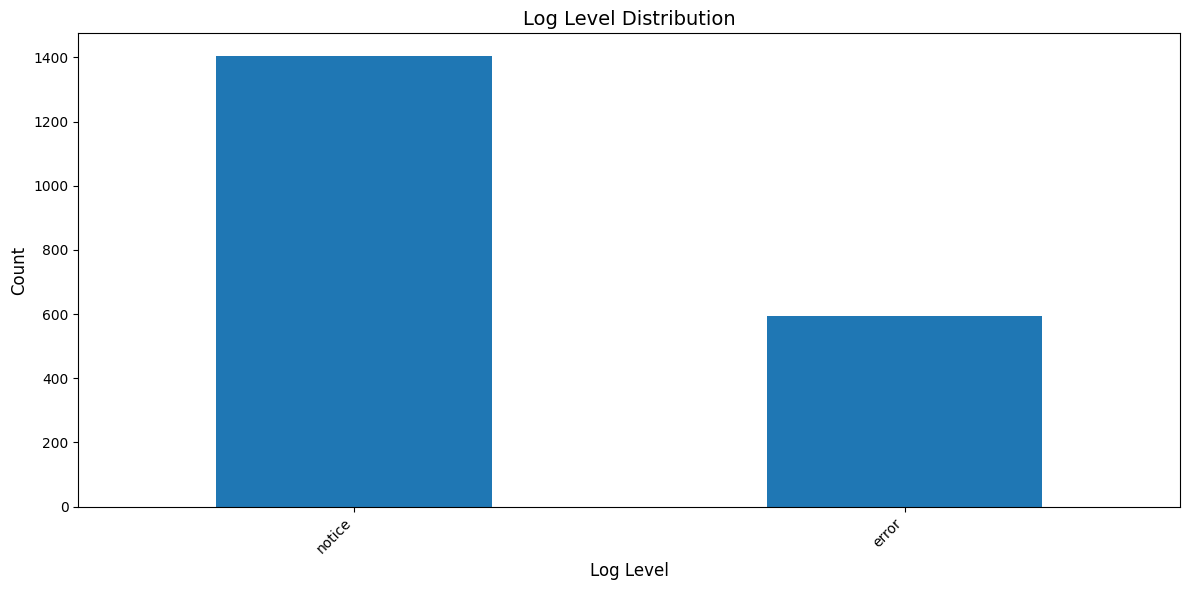

In [9]:
level_counts = parsed_df["log_level"].value_counts()

if not level_counts.empty:
    ax = level_counts.plot(kind="bar")
    ax.set_title("Log Level Distribution")
    ax.set_xlabel("Log Level")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_dir / "log_level_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No log levels available for plotting.")

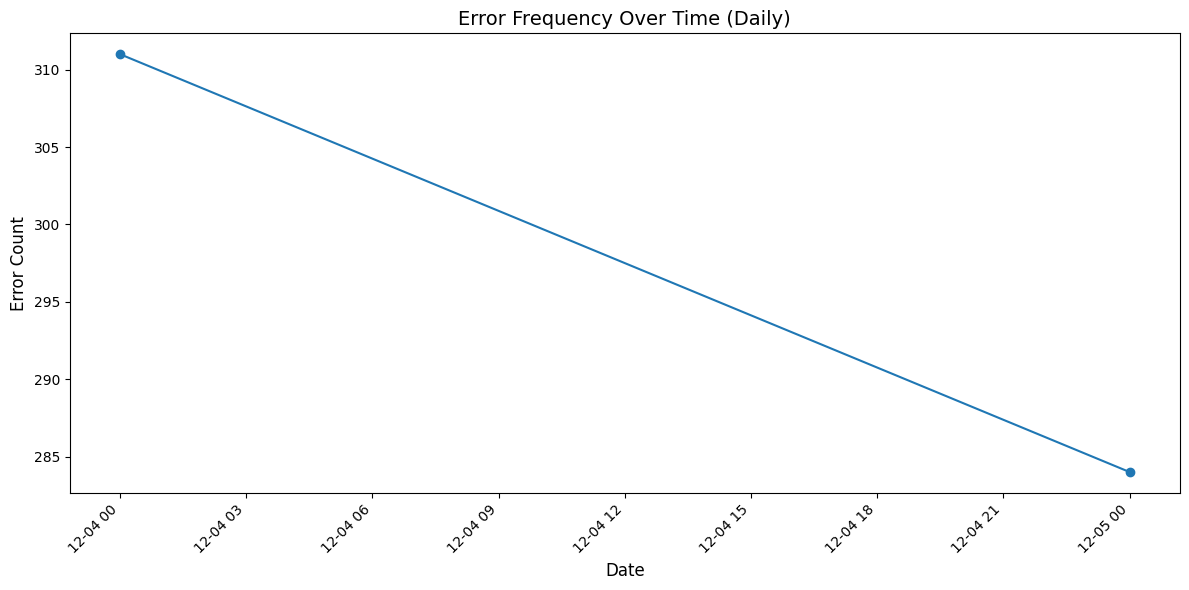

In [10]:
if not error_df.empty:
    daily_errors = error_df.groupby(error_df["timestamp"].dt.floor("D")).size().sort_index()

    if not daily_errors.empty:
        ax = daily_errors.plot(kind="line", marker="o")
        ax.set_title("Error Frequency Over Time (Daily)")
        ax.set_xlabel("Date")
        ax.set_ylabel("Error Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(output_dir / "error_frequency_daily.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No daily error data found.")
else:
    print("No error rows found for daily trend plot.")

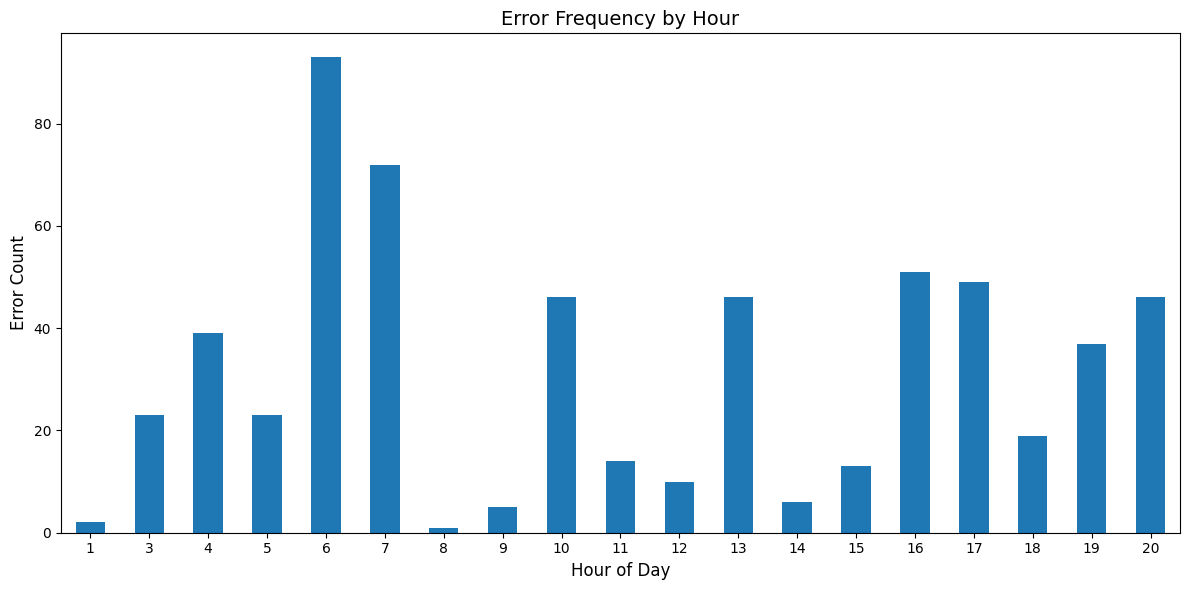

In [11]:
if not error_df.empty:
    hourly_errors = error_df.groupby(error_df["timestamp"].dt.hour).size().sort_index()

    if not hourly_errors.empty:
        ax = hourly_errors.plot(kind="bar")
        ax.set_title("Error Frequency by Hour")
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Error Count")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(output_dir / "error_frequency_hourly.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No hourly error data found.")
else:
    print("No error rows found for hourly plot.")

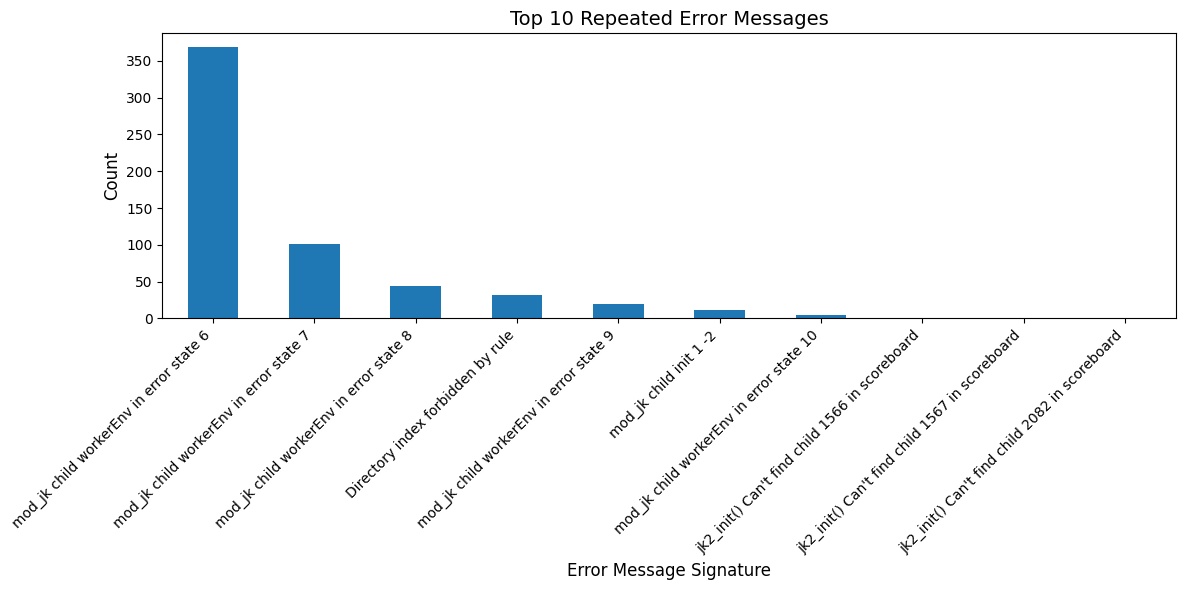

In [12]:
def make_signature(msg):
    msg = re.sub(r"\s+", " ", str(msg)).strip()
    if not msg:
        return "unknown"

    for sep in [":", " - ", "|"]:
        if sep in msg:
            msg = msg.split(sep, 1)[0].strip()
            break

    return msg[:120]

if not error_df.empty:
    error_df = error_df.copy()
    error_df["error_signature"] = error_df["message"].apply(make_signature)

    top_errors = error_df["error_signature"].value_counts().head(10)

    if not top_errors.empty:
        ax = top_errors.plot(kind="bar")
        ax.set_title("Top 10 Repeated Error Messages")
        ax.set_xlabel("Error Message Signature")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(output_dir / "top_error_messages.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No error signatures available.")
else:
    print("No error rows available for top error message plot.")

In [13]:
cluster_source = error_df["message"].dropna().astype(str)
cluster_source = cluster_source[cluster_source.str.strip() != ""]

unique_texts = pd.Series(cluster_source.unique())

if len(unique_texts) >= 3:
    max_messages = min(300, len(unique_texts))
    sample_texts = unique_texts.head(max_messages)

    n_clusters = min(5, len(sample_texts))

    if n_clusters >= 2:
        vectorizer = TfidfVectorizer(
            stop_words="english",
            max_features=1000,
            ngram_range=(1, 2)
        )

        X = vectorizer.fit_transform(sample_texts)

        if X.shape[1] > 0:
            km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = km.fit_predict(X)

            cluster_df = pd.DataFrame({
                "error_message": sample_texts,
                "cluster": labels
            })

            display(cluster_df.head(10))

            terms = vectorizer.get_feature_names_out()
            order_centroids = km.cluster_centers_.argsort()[:, ::-1]

            print("\nTop terms per cluster:")
            for i in range(n_clusters):
                top_terms = [terms[ind] for ind in order_centroids[i, :5]]
                print(f"Cluster {i}: {', '.join(top_terms)}")

            cluster_df.to_csv(output_dir / "error_clusters.csv", index=False)
        else:
            print("TF-IDF produced no features.")
    else:
        print("Not enough unique messages for clustering.")
else:
    print("Not enough error messages for clustering.")

,error_message,cluster
0,mod_jk child workerEnv in error state 6,1
1,mod_jk child workerEnv in error state 7,1
2,Directory index forbidden by rule: /var/www/html/,2
3,mod_jk child workerEnv in error state 8,1
4,mod_jk child workerEnv in error state 10,1
5,mod_jk child workerEnv in error state 9,1
6,jk2_init() Can't find child 1566 in scoreboard,4
7,jk2_init() Can't find child 1567 in scoreboard,2
8,mod_jk child init 1 -2,0
9,jk2_init() Can't find child 2082 in scoreboard,3



Top terms per cluster:
Cluster 0: init, child init, mod_jk child, mod_jk, child
Cluster 1: workerenv error, error state, workerenv, state, error
Cluster 2: scoreboard, jk2_init child, jk2_init, child, 1567
Cluster 3: 2082, child 2082, 2082 scoreboard, jk2_init child, scoreboard
Cluster 4: 1566 scoreboard, child 1566, 1566, jk2_init child, scoreboard


In [14]:
print("Cleaned DataFrame preview:")
display(df.head(10))

print("Summary metrics:")
display(summary)

print("Top repeated error messages:")
if not error_df.empty and "error_signature" in error_df.columns:
    display(error_df["error_signature"].value_counts().head(10).to_frame("count"))

Cleaned DataFrame preview:


,timestamp_raw,log_level,client,message,parsed_status,line_no,raw_line,timestamp,date,hour,weekday
0,Sun Dec 04 04:47:44 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,1,[Sun Dec 04 04:47:44 2005] [notice] workerEnv....,2005-12-04 04:47:44,2005-12-04,4,Sunday
1,Sun Dec 04 04:47:44 2005,error,unknown,mod_jk child workerEnv in error state 6,success,2,[Sun Dec 04 04:47:44 2005] [error] mod_jk chil...,2005-12-04 04:47:44,2005-12-04,4,Sunday
2,Sun Dec 04 04:51:08 2005,notice,unknown,jk2_init() Found child 6725 in scoreboard slot 10,success,3,[Sun Dec 04 04:51:08 2005] [notice] jk2_init()...,2005-12-04 04:51:08,2005-12-04,4,Sunday
3,Sun Dec 04 04:51:09 2005,notice,unknown,jk2_init() Found child 6726 in scoreboard slot 8,success,4,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...,2005-12-04 04:51:09,2005-12-04,4,Sunday
4,Sun Dec 04 04:51:09 2005,notice,unknown,jk2_init() Found child 6728 in scoreboard slot 6,success,5,[Sun Dec 04 04:51:09 2005] [notice] jk2_init()...,2005-12-04 04:51:09,2005-12-04,4,Sunday
5,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,6,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
6,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,7,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
7,Sun Dec 04 04:51:14 2005,notice,unknown,workerEnv.init() ok /etc/httpd/conf/workers2.p...,success,8,[Sun Dec 04 04:51:14 2005] [notice] workerEnv....,2005-12-04 04:51:14,2005-12-04,4,Sunday
8,Sun Dec 04 04:51:18 2005,error,unknown,mod_jk child workerEnv in error state 6,success,9,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...,2005-12-04 04:51:18,2005-12-04,4,Sunday
9,Sun Dec 04 04:51:18 2005,error,unknown,mod_jk child workerEnv in error state 6,success,10,[Sun Dec 04 04:51:18 2005] [error] mod_jk chil...,2005-12-04 04:51:18,2005-12-04,4,Sunday


Summary metrics:


,Metric,Value
0,Total raw lines,2000
1,Parsed lines,2000
2,Unparsed lines,0
3,Blank lines,0
4,Parse success rate (%),100.0
5,Error lines,595
6,Unique log levels,2
7,Time span,2005-12-04 04:47:44 to 2005-12-05 19:15:57


Top repeated error messages:


,count
error_signature,
mod_jk child workerEnv in error state 6,369
mod_jk child workerEnv in error state 7,101
mod_jk child workerEnv in error state 8,44
Directory index forbidden by rule,32
mod_jk child workerEnv in error state 9,20
mod_jk child init 1 -2,12
mod_jk child workerEnv in error state 10,5
jk2_init() Can't find child 1566 in scoreboard,1
jk2_init() Can't find child 1567 in scoreboard,1
